In [9]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


# Methods
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

# What will we get?
How well do jobs and skills pay for Data Analysts?

# Salary Distribution by Job Title

In [10]:
# filter for the job titles and country
df_VN = df[(df['job_country'] == 'Vietnam')].dropna(subset=['salary_year_avg'])
df_VN

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3016,Data Scientist,CI/XAB - Big data Hadoop developer,Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-01-06 13:45:37,False,False,Vietnam,year,50400.0,NaN,Bosch Group,"[java, hadoop, spark, unix, sap, yarn]","{'analyst_tools': ['sap'], 'libraries': ['hado..."
22893,Business Analyst,Strategic Insight & Business Intelligence Spec...,Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-12-12 13:47:24,False,False,Vietnam,year,64800.0,NaN,Japan Tobacco International,"[qlik, powerpoint, excel]","{'analyst_tools': ['qlik', 'powerpoint', 'exce..."
45585,Machine Learning Engineer,BD Oracle Data Modeler,Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-06-24 06:24:08,False,False,Vietnam,year,79200.0,NaN,Bosch Group,"[java, python, r, sql, oracle, sap]","{'analyst_tools': ['sap'], 'cloud': ['oracle']..."
134303,Data Analyst,Data Analyst Team Leader,"Hanoi, Hoàn Kiếm, Hanoi, Vietnam",via Ai-Jobs.net,Full-time,False,Vietnam,2023-02-15 08:34:55,True,False,Vietnam,year,111175.0,NaN,Ninja Van,"[sql, power bi]","{'analyst_tools': ['power bi'], 'programming':..."
140484,Data Scientist,Data Scientist (Mid/Sr),Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-09-06 08:35:27,False,False,Vietnam,year,70000.0,NaN,SmartDev,"[python, c]","{'programming': ['python', 'c']}"
140810,Data Engineer,BD/XAB Data Architect,Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-04-12 08:28:17,False,False,Vietnam,year,165000.0,NaN,Bosch Group,"[java, hadoop, sap, flow]","{'analyst_tools': ['sap'], 'libraries': ['hado..."
141741,Data Scientist,Research Engineer - Data Science,"Ho Chi Minh City, Vietnam",via Ai-Jobs.net,Full-time,False,Vietnam,2023-02-06 08:41:53,False,False,Vietnam,year,200000.0,NaN,Trusting Social,"[python, c++, java, javascript, tensorflow, py...","{'libraries': ['tensorflow', 'pytorch', 'mxnet..."
142149,Machine Learning Engineer,AI Generated Content (AIGC) Rewriter - Vietnam...,Vietnam,via Ai-Jobs.net,Full-time,False,Vietnam,2023-04-25 08:10:32,False,False,Vietnam,year,64800.0,NaN,Welocalize,NaN,NaN
149765,Data Engineer,Data Engineer (Hybrid),"Ho Chi Minh City, Vietnam",via Ai-Jobs.net,Full-time,False,Vietnam,2023-01-17 08:25:10,False,False,Vietnam,year,96773.0,NaN,KNOREX,"[python, scala, mongodb, mongodb, spark]","{'databases': ['mongodb'], 'libraries': ['spar..."
172823,Data Engineer,Data Engineer,"Ho Chi Minh City, Vietnam",via Ai-Jobs.net,Full-time,False,Vietnam,2023-02-17 15:17:20,False,False,Vietnam,year,98283.0,NaN,Carousell Group,"[python, golang, bash, kafka, flask, terraform]","{'libraries': ['kafka'], 'other': ['terraform'..."


In [11]:
job_titles = df_VN['job_title_short'].value_counts().index[:6].tolist()

# filter the df for the top 6 job titles
df_VN_top6 = df_VN[df_VN['job_title_short'].isin(job_titles)]

# order the job titles by median salary
job_order = df_VN_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles

['Data Engineer',
 'Data Analyst',
 'Machine Learning Engineer',
 'Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

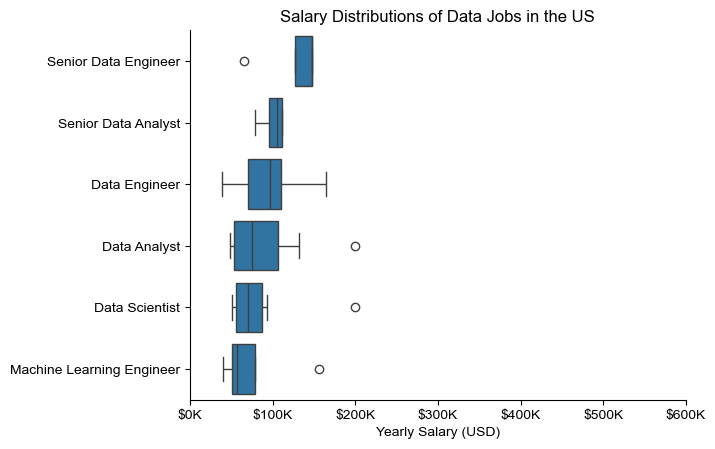

In [ ]:
sns.boxplot(data=df_VN_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

# this is all the same
plt.title('Salary Distributions of Data Jobs in Vietnam')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()